In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# load the features dataframe
df = pd.read_csv('features.csv')

# enter in each row of the features dataframe the optimal weights (downloaded in the get_historical_optimal_weights.ipynb file) for the following week (which will be the variable to predict)
next_week_optimal_weights= pd.read_csv("df_optimal_weights.csv")
next_week_optimal_weights = next_week_optimal_weights.rename(columns=lambda x: "next_week_opt_weight_" + x)
next_week_optimal_weights= next_week_optimal_weights[1:].copy()
next_week_optimal_weights.loc[len(next_week_optimal_weights)+1] = [np.nan] * next_week_optimal_weights.shape[1]
next_week_optimal_weights.index = pd.RangeIndex(start=0, stop=len(next_week_optimal_weights), step=1)
df= pd.concat([df, next_week_optimal_weights], axis=1)
df = df.dropna()

# set the size of the train set
train_size = int(len(df) * 0.70)

# divide the dataset into train and test
X_train = df.drop(columns=["next_week_opt_weight_EXV1.DE","next_week_opt_weight_EXV2.DE","next_week_opt_weight_EXV3.DE","next_week_opt_weight_EXV5.DE","next_week_opt_weight_EXV6.DE"]).iloc[:train_size]
y_train = df[["next_week_opt_weight_EXV1.DE","next_week_opt_weight_EXV2.DE","next_week_opt_weight_EXV3.DE","next_week_opt_weight_EXV5.DE","next_week_opt_weight_EXV6.DE"]].iloc[:train_size]
X_test = df.drop(columns=["next_week_opt_weight_EXV1.DE","next_week_opt_weight_EXV2.DE","next_week_opt_weight_EXV3.DE","next_week_opt_weight_EXV5.DE","next_week_opt_weight_EXV6.DE"]).iloc[train_size:]
y_test = df[["next_week_opt_weight_EXV1.DE","next_week_opt_weight_EXV2.DE","next_week_opt_weight_EXV3.DE","next_week_opt_weight_EXV5.DE","next_week_opt_weight_EXV6.DE"]].iloc[train_size:]

In [3]:
# start the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [4]:
# perform prediction on the test set
y_pred = rf_model.predict(X_test)

# calculate the Mean Squared Error MSE
mse = mean_squared_error(y_test, y_pred)
print(f'Errore Quadratico Medio: {mse}')

Errore Quadratico Medio: 0.03149893678205128


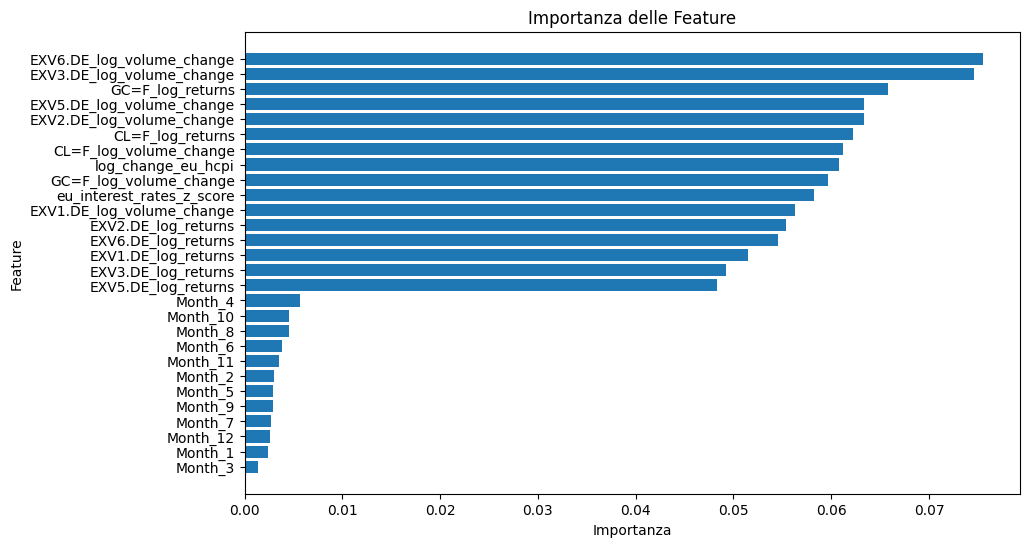

In [5]:
# extract feature importances
feature_importances = rf_model.feature_importances_

# df with different importances
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# graph representation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importanza')
plt.ylabel('Feature')
plt.title('Importanza delle Feature')
plt.gca().invert_yaxis()
plt.show()

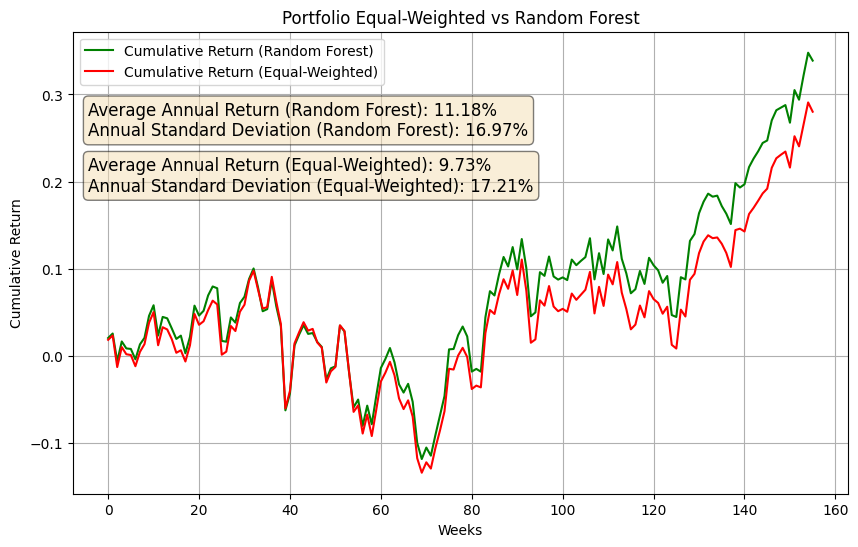

In [7]:
# import the functions that calculate the performance of a portfolio
from portfolio_metrics_functions import get_weekly_returns, compare_portfolio_performance

weekly_returns= get_weekly_returns(pd.read_csv("stocks_data_adj_close.csv"))
compare_portfolio_performance(weekly_returns= weekly_returns[int(len(weekly_returns) * 0.7):], 
                              weights_custom= y_pred,  
                              weights_equal= pd.read_csv("df_equally_weighted_portfolio_weights.csv").to_numpy()[int(len(weekly_returns) * 0.7):], 
                              plot_title="Portfolio Equal-Weighted vs Random Forest", 
                              savefig_name="random_forest_portfolio_performance.png", 
                              p1_name= "Equal-Weighted", 
                              p2_name= "Random Forest")